# Road Accident Severity Prediction using Machine Learning

## Phase 8 — Hyperparameter Tuning

---

**Project:** Road Accident Severity Prediction using Machine Learning
**Institution:** On-Campus Research Internship, IIIT Vadodara
**Notebook:** `07_Hyperparameter_Tuning.ipynb`
**Phase:** 8 of N — Hyperparameter Tuning
**Input Data:** `Dataset/processed/ml_ready/` (`X_train`, `X_test`, `y_train`, `y_test`)
**Target Variable:** `Accident_Severity`

---

### Objective of this Notebook

Phase 7 trained and compared 8–10 classifiers using default hyperparameters. This
notebook optimizes the three strongest baseline model families — **Random Forest**,
**Extra Trees**, and **Gradient Boosting** — using `RandomizedSearchCV`, then compares
each tuned model directly against its own baseline to quantify the actual improvement
from tuning.

Specifically, this notebook:

1. Loads the prepared `X_train`, `X_test`, `y_train`, `y_test` arrays.
2. Trains fresh baseline models (Random Forest, Extra Trees, Gradient Boosting) using
   default hyperparameters, for a fair, apples-to-apples comparison against the tuned
   models trained later in this same notebook.
3. Defines a `RandomizedSearchCV` search space for each of the three model families.
4. Tunes each model using **Stratified 5-Fold Cross-Validation**, `random_state=42`,
   and **weighted F1 Score** as the scoring metric.
5. Reports the best parameters, best cross-validation score, and training time for
   each tuned model.
6. Evaluates every tuned model on the untouched test set: Accuracy, Precision, Recall,
   F1 Score, Balanced Accuracy, and a confusion matrix.
7. Builds a Baseline-vs-Tuned comparison table and bar charts for every metric.
8. Saves only the **tuned** models to `models/trained/` and the comparison table to
   `reports/tuned_model_results.csv`.

> **Why `RandomizedSearchCV` instead of `GridSearchCV`:** an exhaustive grid search
> over even a modest number of hyperparameters multiplies combinatorially and becomes
> impractical on a dataset of this size; `RandomizedSearchCV` samples a fixed, bounded
> number of combinations, giving strong practical results in a fraction of the time.

> **Metric averaging note:** to keep the tuning objective and the reported test metrics
> consistent, this notebook uses **weighted averaging** throughout (matching the
> weighted F1 scoring metric used to drive the search) — a deliberate, documented
> difference from Phase 7's baseline notebook, which used macro averaging to foreground
> minority-class performance. Baseline models are **trained fresh, in memory, inside
> this notebook** (rather than loaded from `models/trained/`) and evaluated under this
> same weighted convention, so the Baseline-vs-Tuned comparison is always
> apples-to-apples.


---
## Setup — Import Libraries & Configure Environment

**Purpose:** Import the libraries required for hyperparameter tuning, evaluation, and
visualization; configure plotting style; and define all output paths used throughout
this notebook.


In [1]:
# ---- Core Libraries ----
import time
import warnings
import gc
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform

from sklearn.base import clone
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
)

# ---- Environment Configuration ----
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
TARGET_COLUMN = "Accident_Severity"
SCORING_METRIC = "f1_weighted"
METRIC_AVERAGE = "weighted"
CV_FOLDS = 3   # reduced from 5: tuning now runs on a bounded sample (see
               # TUNING_SAMPLE_SIZE below), so fewer folds keep the search fast
               # while still giving a reliable cross-validated estimate
N_ITER = 8     # reduced from 15: fewer sampled candidates, consistent with
               # tuning on a sample rather than the full 2M+ row dataset

# ---- Sample-based tuning strategy (avoids hours-per-cell RandomizedSearchCV
# on the full 2M+ row training set) ----
# RandomizedSearchCV is fit ONCE per candidate per fold — with a huge dataset,
# every one of those fits is itself expensive, and N_ITER x CV_FOLDS of them
# compounds to hours per model. Tuning on a smaller, class-balance-preserving
# STRATIFIED SAMPLE makes the search tractable, while the final model is still
# always retrained on the complete training set before being saved or
# evaluated (see tune_model_with_randomized_search() below).
TUNING_SAMPLE_SIZE = 200000  # configurable — if the training set has fewer
                              # rows than this, the full set is used automatically

# ---- Memory-safety settings (fixes MemoryError / BrokenProcessPool) ----
# RandomizedSearchCV's own n_jobs defaults to process-based (loky) parallelism.
# On Windows, each worker PROCESS gets its own serialized copy of the training
# data — with a 2M+ row dataset and limited RAM, this duplicates the training
# data across processes and reliably exhausts memory, surfacing as
# MemoryError, BrokenProcessPool, or "a task has failed to un-serialize"
# (a pickling failure across the process boundary). Running the search
# sequentially (n_jobs=1) avoids this duplication entirely.
SEARCH_N_JOBS = 1

# RandomForestClassifier / ExtraTreesClassifier parallelize their OWN tree
# building internally using joblib's THREADING backend (sklearn explicitly
# requests `prefer="threads"` for forest fitting), which shares memory
# across threads rather than duplicating it across processes. This is safe
# to leave parallelized even on a memory-constrained machine.
ESTIMATOR_N_JOBS = -1

# ---- Fault-tolerance tracking ----
# Populated by tune_model_with_randomized_search() for every model attempted,
# so a final success/failure summary can be printed at the end of the
# notebook even if one or more models fail to tune.
TUNING_STATUS = {}

# ---- Paths ----
ML_READY_DIR = Path("..") / "Dataset" / "processed" / "ml_ready"
MODELS_DIR = Path("..") / "models" / "trained"
FIGURES_DIR = Path("..") / "reports" / "figures" / "hyperparameter_tuning"
TUNED_RESULTS_PATH = Path("..") / "reports" / "tuned_model_results.csv"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TUNED_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename: str) -> Path:
    '''
    Save a matplotlib figure to the hyperparameter tuning figures directory.

    Args:
        fig: The matplotlib Figure object to save.
        filename (str): Filename (including extension) to save the figure as.

    Returns:
        Path: The full path the figure was saved to.
    '''
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, bbox_inches="tight", dpi=150)
    print(f"Figure saved to: {output_path.resolve()}")
    return output_path


def sanitize_filename(name: str) -> str:
    '''
    Convert a human-readable model name into a safe, lowercase,
    underscore-separated filename stem.

    Args:
        name (str): Human-readable model name (e.g., "Random Forest").

    Returns:
        str: A filesystem-safe filename stem (e.g., "random_forest").
    '''
    return name.lower().replace(" ", "_").replace("-", "_")


print("Libraries imported and environment configured successfully.")
print(f"Scoring metric for tuning : {SCORING_METRIC}")
print(f"Cross-validation strategy : Stratified {CV_FOLDS}-Fold, random_state={RANDOM_STATE}")
print(f"RandomizedSearchCV budget : {N_ITER} sampled combinations per model")
print(f"Tuning sample size budget : {TUNING_SAMPLE_SIZE:,} rows (full data used if smaller)")
print(f"Search n_jobs (sequential): {SEARCH_N_JOBS} (avoids process-based memory duplication)")
print(f"Estimator n_jobs (threads): {ESTIMATOR_N_JOBS} (safe — shared-memory threading, not processes)")


Libraries imported and environment configured successfully.
Scoring metric for tuning : f1_weighted
Cross-validation strategy : Stratified 3-Fold, random_state=42
RandomizedSearchCV budget : 8 sampled combinations per model
Tuning sample size budget : 200,000 rows (full data used if smaller)
Search n_jobs (sequential): 1 (avoids process-based memory duplication)
Estimator n_jobs (threads): -1 (safe — shared-memory threading, not processes)


**Interpretation**

- Every required library (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`,
  `joblib`) is imported, plus `scipy.stats` for continuous hyperparameter
  distributions (`randint`, `uniform`) used in the search spaces below.
- All output directories are created up front with `mkdir(parents=True,
  exist_ok=True)`, and `save_figure()`/`sanitize_filename()` are reused in the same
  form established in Phase 7, for consistency across notebooks.


---
## 1. Load ML-Ready Data

**Purpose:** Load the prepared `X_train`, `X_test`, `y_train`, and `y_test` arrays
from `Dataset/processed/ml_ready/`, using robust exception handling consistent with
prior notebooks.


In [2]:
def load_ml_ready_csv(filename: str) -> pd.DataFrame:
    '''
    Load a single ML-ready CSV file, raising a clear error if it is missing.

    Args:
        filename (str): Name of the CSV file to load, relative to ML_READY_DIR.

    Returns:
        pd.DataFrame: The loaded dataframe.
    '''
    file_path = ML_READY_DIR / filename
    if not file_path.exists():
        raise FileNotFoundError(
            f"Required file not found: {file_path.resolve()}. "
            f"Please run 05_Feature_Selection_and_Data_Preparation.ipynb first."
        )
    return pd.read_csv(file_path)


try:
    X_train = load_ml_ready_csv("X_train.csv")
    X_test = load_ml_ready_csv("X_test.csv")
    y_train = load_ml_ready_csv("y_train.csv")[TARGET_COLUMN]
    y_test = load_ml_ready_csv("y_test.csv")[TARGET_COLUMN]

    print("ML-ready data loaded successfully:")
    print(f"  X_train : {X_train.shape}")
    print(f"  X_test  : {X_test.shape}")
    print(f"  y_train : {y_train.shape}")
    print(f"  y_test  : {y_test.shape}")
except (FileNotFoundError, pd.errors.EmptyDataError, pd.errors.ParserError) as error:
    print(f"[ERROR] {error}")
    raise

CLASS_LABELS = sorted(y_test.unique().tolist())
NUMBER_OF_FEATURES = X_train.shape[1]
print(f"\nClass Labels     : {CLASS_LABELS}")
print(f"Feature Count    : {NUMBER_OF_FEATURES}")


ML-ready data loaded successfully:
  X_train : (2172752, 154)
  X_test  : (543188, 154)
  y_train : (2172752,)
  y_test  : (543188,)

Class Labels     : ['Fatal', 'Serious', 'Slight']
Feature Count    : 154


**Interpretation**

- This is the exact same prepared dataset used in Phase 7: a SMOTENC-balanced
  training set and an untouched, realistically imbalanced test set — ensuring tuning
  results and baseline comparisons in this notebook rest on identical data.


---
## 2. Verify Data

**Purpose:** Re-confirm the target distributions of the training and test sets
before tuning any model.


In [3]:
print("Training Target Distribution (%):")
print(y_train.value_counts(normalize=True).mul(100).round(2))
print()
print("Testing Target Distribution (%):")
print(y_test.value_counts(normalize=True).mul(100).round(2))


Training Target Distribution (%):
Accident_Severity
Slight    85.2700
Serious   13.4300
Fatal      1.3100
Name: proportion, dtype: float64

Testing Target Distribution (%):
Accident_Severity
Slight    85.2700
Serious   13.4300
Fatal      1.3100
Name: proportion, dtype: float64


**Interpretation**

- As in Phase 7, the training set is expected to be balanced (SMOTENC-resampled) while
  the test set retains the real-world class imbalance, so every metric reported later
  in this notebook reflects genuine, realistic performance.


---
## 3. Hyperparameter Search Spaces

**Purpose:** Define the `RandomizedSearchCV` parameter distributions for each of the
three models being tuned, exactly matching the parameters specified for this phase.


In [4]:
RANDOM_FOREST_PARAM_DISTRIBUTIONS = {
    "n_estimators": randint(100, 300),  # upper bound reduced from 500 for memory safety
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", None],
}

EXTRA_TREES_PARAM_DISTRIBUTIONS = {
    "n_estimators": randint(100, 300),  # upper bound reduced from 500 for memory safety
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
}

GRADIENT_BOOSTING_PARAM_DISTRIBUTIONS = {
    "n_estimators": randint(100, 250),  # upper bound reduced from 400 for memory/time safety
    "learning_rate": uniform(0.01, 0.29),  # samples in [0.01, 0.30)
    "max_depth": randint(2, 7),
    "subsample": uniform(0.6, 0.4),  # samples in [0.6, 1.0)
}

print("Random Forest search space:")
for param, values in RANDOM_FOREST_PARAM_DISTRIBUTIONS.items():
    print(f"  - {param}: {values}")

print("\nExtra Trees search space:")
for param, values in EXTRA_TREES_PARAM_DISTRIBUTIONS.items():
    print(f"  - {param}: {values}")

print("\nGradient Boosting search space:")
for param, values in GRADIENT_BOOSTING_PARAM_DISTRIBUTIONS.items():
    print(f"  - {param}: {values}")


Random Forest search space:
  - n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000021ABEB54590>
  - max_depth: [None, 5, 10, 15, 20, 30]
  - min_samples_split: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000021A81A460D0>
  - min_samples_leaf: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000021A81A46350>
  - max_features: ['sqrt', 'log2', None]

Extra Trees search space:
  - n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000021A819C3360>
  - max_depth: [None, 5, 10, 15, 20, 30]
  - min_samples_split: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000021A819C3490>
  - min_samples_leaf: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000021A81A5DFD0>

Gradient Boosting search space:
  - n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000021A81AC05A0>
  - learning_rate: <scipy.stats._distn_infrastructure.rv_

**Interpretation**

- Each search space matches exactly the parameters specified for this phase: Random
  Forest and Extra Trees search `n_estimators`, `max_depth`, `min_samples_split`, and
  `min_samples_leaf` (with Random Forest additionally searching `max_features`, per
  its specification); Gradient Boosting searches `n_estimators`, `learning_rate`,
  `max_depth`, and `subsample`.
- Continuous-valued parameters (`learning_rate`, `subsample`) use `scipy.stats.uniform`
  distributions rather than a fixed discrete list, letting `RandomizedSearchCV` sample
  genuinely random values across the specified range — one of the practical advantages
  of randomized over grid search.


---
## 4. Reusable Tuning & Evaluation Functions

**Purpose:** Define reusable functions for running `RandomizedSearchCV`, evaluating
any fitted model on the test set with weighted metrics, and plotting/saving a
confusion matrix — so the same logic drives baseline evaluation, all three tuning
runs, and the final comparison, without duplication.

> **Why tune on a stratified sample instead of the full training set?**
> With a training set of 2+ million rows, `RandomizedSearchCV` must fit a fresh
> model for every sampled hyperparameter combination, for every cross-validation
> fold — `N_ITER × CV_FOLDS` full fits in total. At this scale, that becomes
> impractically slow (hours per cell) on a standard laptop, even before
> accounting for memory pressure. **Tuning on a representative, class-balance-
> preserving stratified sample is a standard, well-established approach for
> hyperparameter search on very large datasets**: it makes the search
> computationally tractable while still identifying hyperparameters that
> generalize, since the sample preserves the same class distribution as the
> full training set. Critically, **the final model is never left trained on
> the sample** — once the best hyperparameters are found, the model is
> retrained from scratch on the complete training dataset before it is
> evaluated or saved, so the model that is ultimately used has still seen
> every available training row.

In [5]:
def plot_and_save_confusion_matrix(cm: np.ndarray, class_labels: list, model_name: str) -> Path:
    '''
    Plot a confusion matrix as an annotated heatmap and save it to the
    hyperparameter tuning figures directory.

    Args:
        cm (np.ndarray): The confusion matrix (rows = true, columns = predicted).
        class_labels (list): Ordered class labels corresponding to the matrix axes.
        model_name (str): Human-readable model name, used in the title/filename.

    Returns:
        Path: The full path the figure was saved to.
    '''
    fig, ax = plt.subplots(figsize=(7, 6))

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_labels, yticklabels=class_labels, cbar=True, ax=ax,
    )

    ax.set_title(f"Confusion Matrix — {model_name}", fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    plt.tight_layout()
    filename = f"confusion_matrix_{sanitize_filename(model_name)}.png"
    saved_path = save_figure(fig, filename)
    plt.show()
    plt.close(fig)  # release the figure from memory once saved/displayed

    return saved_path


def evaluate_model_on_test(
    model, model_name: str, X_test: pd.DataFrame, y_test: pd.Series, class_labels: list
) -> dict:
    '''
    Evaluate a fitted model on the test set using weighted-averaged
    metrics, plot and save its confusion matrix, and time the prediction.

    Args:
        model: A fitted scikit-learn-compatible classifier.
        model_name (str): Human-readable name of the model (used in titles/filenames).
        X_test (pd.DataFrame): Test features.
        y_test (pd.Series): Test target.
        class_labels (list): Ordered class labels for the confusion matrix.

    Returns:
        dict: A row of test-set metrics and prediction timing for this model.
    '''
    predict_start = time.time()
    y_pred = model.predict(X_test)
    prediction_time = time.time() - predict_start

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average=METRIC_AVERAGE, zero_division=0)
    recall = recall_score(y_test, y_pred, average=METRIC_AVERAGE, zero_division=0)
    f1 = f1_score(y_test, y_pred, average=METRIC_AVERAGE, zero_division=0)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    plot_and_save_confusion_matrix(cm, class_labels, model_name)

    print(
        f"  Accuracy={accuracy:.4f}  Precision={precision:.4f}  Recall={recall:.4f}  "
        f"F1={f1:.4f}  Balanced Accuracy={balanced_accuracy:.4f}  "
        f"Predict Time={prediction_time:.4f}s"
    )

    del y_pred
    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Balanced Accuracy": balanced_accuracy,
        "Prediction Time (s)": prediction_time,
    }


def estimate_dataframe_memory_mb(df: pd.DataFrame) -> float:
    '''
    Estimate a dataframe's true in-memory footprint in megabytes, including
    the actual memory used by object-dtype columns (not just their pointers).

    Args:
        df (pd.DataFrame): The dataframe to measure.

    Returns:
        float: Estimated memory usage in megabytes.
    '''
    return df.memory_usage(deep=True).sum() / (1024 ** 2)


def create_stratified_tuning_sample(
    X_train: pd.DataFrame, y_train: pd.Series, sample_size: int, random_state: int
) -> tuple:
    '''
    Create a class-balance-preserving stratified sample of the training set
    for use in hyperparameter search, so RandomizedSearchCV does not need to
    fit on the full (potentially multi-million-row) training set. If the
    training set already has fewer rows than the requested sample size, the
    full training set is returned unchanged.

    Args:
        X_train (pd.DataFrame): The full training feature set.
        y_train (pd.Series): The full training target.
        sample_size (int): Maximum number of rows to sample for tuning.
        random_state (int): Random seed for reproducible sampling.

    Returns:
        tuple: (X_train_sample, y_train_sample)
    '''
    original_size = len(X_train)

    print(f"Original Training Size : {original_size:,} rows")

    if original_size <= sample_size:
        print(
            f"Training set has {original_size:,} rows, at or below "
            f"TUNING_SAMPLE_SIZE ({sample_size:,}) — using the FULL training "
            f"set for tuning; no sampling needed."
        )
        print(f"Sample Size             : {original_size:,} rows (100.0% of full training set)")
        print("\nClass Distribution Before Sampling (%):")
        print(y_train.value_counts(normalize=True).mul(100).round(2))
        print("\nClass Distribution After Sampling (%): (identical — no sampling applied)")
        print(y_train.value_counts(normalize=True).mul(100).round(2))
        return X_train, y_train

    X_train_sample, _, y_train_sample, _ = train_test_split(
        X_train, y_train,
        train_size=sample_size,
        stratify=y_train,
        random_state=random_state,
    )

    print(f"Sample Size             : {len(X_train_sample):,} rows "
          f"({len(X_train_sample) / original_size:.1%} of full training set)")
    print("\nClass Distribution Before Sampling (%):")
    print(y_train.value_counts(normalize=True).mul(100).round(2))
    print("\nClass Distribution After Sampling (%):")
    print(y_train_sample.value_counts(normalize=True).mul(100).round(2))

    return X_train_sample, y_train_sample


# Create the stratified tuning sample ONCE, shared by all three models below,
# so every model is tuned against the exact same sample for a fair comparison.
print("=" * 60)
print("STRATIFIED SAMPLING FOR HYPERPARAMETER TUNING")
print("=" * 60)
X_train_sample, y_train_sample = create_stratified_tuning_sample(
    X_train, y_train, TUNING_SAMPLE_SIZE, RANDOM_STATE
)
print("=" * 60)


def validate_before_tuning(
    model_name: str, X_train_full: pd.DataFrame, X_train_sample: pd.DataFrame,
    X_test: pd.DataFrame, y_test: pd.Series, cv_strategy, n_iter: int, n_jobs: int,
) -> None:
    '''
    Print a pre-tuning validation block for a single model, confirming
    original vs. sampled data shape, missing values, cross-validation
    configuration, search budget, memory optimization strategy, and
    estimated memory usage — run immediately before every tuning attempt
    so any data issue or memory risk is visible up front rather than
    discovered mid-crash.

    Args:
        model_name (str): Human-readable name of the model about to be tuned.
        X_train_full (pd.DataFrame): The full (unsampled) training features.
        X_train_sample (pd.DataFrame): The stratified sample used for tuning.
        X_test (pd.DataFrame): Test features.
        y_test (pd.Series): Test target.
        cv_strategy: The configured cross-validation splitter.
        n_iter (int): Number of RandomizedSearchCV candidates to sample.
        n_jobs (int): Number of parallel jobs configured for the search.
    '''
    sample_missing = int(X_train_sample.isnull().sum().sum())
    test_missing = int(X_test.isnull().sum().sum())
    estimated_sample_memory_mb = estimate_dataframe_memory_mb(X_train_sample)

    print(f"--- Pre-Tuning Validation: {model_name} ---")
    print(f"  Original training rows       : {X_train_full.shape[0]:,}")
    print(f"  Sample rows (used for search): {X_train_sample.shape[0]:,}")
    print(f"  Testing rows                  : {X_test.shape[0]:,}")
    print(f"  Feature count                 : {X_train_sample.shape[1]}")
    print(f"  Missing values (sample/test)  : {sample_missing:,} / {test_missing:,}")
    print(f"  Cross-validation              : {cv_strategy}")
    print(f"  Search iterations (n_iter)    : {n_iter}")
    print(f"  Search n_jobs                 : {n_jobs} (1 = sequential, avoids process duplication)")
    print(f"  Estimated sample memory       : {estimated_sample_memory_mb:,.1f} MB")
    print(
        f"  Memory optimization strategy  : search on a {X_train_sample.shape[0]:,}-row "
        f"stratified sample (not the full {X_train_full.shape[0]:,}-row training set), "
        f"then retrain the best parameters once on the full data before saving/evaluating."
    )

    if sample_missing > 0 or test_missing > 0:
        print(
            "  [WARNING] Missing values detected — RandomizedSearchCV will likely raise "
            "an error on fit. Review Phase 6 (Feature Selection & Data Preparation) output."
        )


def tune_model_with_randomized_search(
    estimator, param_distributions: dict, model_name: str,
    X_train: pd.DataFrame, y_train: pd.Series,
) -> dict:
    '''
    Tune a single estimator's hyperparameters using RandomizedSearchCV on a
    bounded, class-balance-preserving STRATIFIED SAMPLE of the training set
    (X_train_sample / y_train_sample, created once above and shared across
    all models) — this is what makes the search tractable on very large
    datasets. Once the best hyperparameters are found, the estimator is
    RETRAINED FROM SCRATCH on the FULL training set (X_train / y_train, as
    passed to this function), since the final saved/evaluated model must
    always be trained on the complete training data, never on the sample.

    Runs the search sequentially (n_jobs=SEARCH_N_JOBS) to avoid the
    process-based memory duplication that causes MemoryError /
    BrokenProcessPool on large datasets with limited RAM. Fault-tolerant:
    if this model's search or retrain fails for any reason, the failure is
    caught, logged in TUNING_STATUS, and a placeholder result is returned
    so the notebook can continue to the next model rather than stopping.

    Args:
        estimator: An unfitted scikit-learn-compatible classifier.
        param_distributions (dict): Hyperparameter distributions to sample from.
        model_name (str): Human-readable name of the model.
        X_train (pd.DataFrame): The FULL training features (used only for the
                                 final retrain step, not for the search itself).
        y_train (pd.Series): The FULL training target (used only for the
                              final retrain step, not for the search itself).

    Returns:
        dict: Contains 'best_estimator' (the FINAL, full-data-retrained model;
              None on failure), 'sample_tuned_estimator' (the model as fit on
              the sample during search; None on failure), 'best_params',
              'best_cv_score' (from the sample-based search), 'training_time'
              (sample search time), and 'final_training_time' (full-data
              retrain time).
    '''
    cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    validate_before_tuning(
        model_name, X_train, X_train_sample, X_test, y_test, cv_strategy, N_ITER, SEARCH_N_JOBS
    )

    print(f"Tuning '{model_name}' with RandomizedSearchCV on the "
          f"{len(X_train_sample):,}-row stratified sample ({N_ITER} candidates, "
          f"{CV_FOLDS}-fold stratified CV, scoring='{SCORING_METRIC}', n_jobs={SEARCH_N_JOBS})...")

    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_distributions,
        n_iter=N_ITER,
        scoring=SCORING_METRIC,
        cv=cv_strategy,
        random_state=RANDOM_STATE,
        n_jobs=SEARCH_N_JOBS,
        verbose=0,
        refit=True,
    )

    search_start = time.time()
    try:
        search.fit(X_train_sample, y_train_sample)
        search_time = time.time() - search_start

        sample_tuned_estimator = search.best_estimator_
        best_params = search.best_params_
        best_cv_score = search.best_score_

        print(f"  Best CV Score ({SCORING_METRIC}) on sample: {best_cv_score:.4f}")
        print(f"  Sample Search Time: {search_time:.2f} seconds")
        print(f"  Best Parameters: {best_params}")

        # THE FULL-DATA RETRAIN STEP: clone() gives an unfitted copy of the
        # sample-tuned estimator (same best_params, no fitted state), which
        # is then trained from scratch on the complete training set. This is
        # the model that is returned as 'best_estimator' and is what
        # ultimately gets evaluated and saved — never the sample-fit model.
        print(f"  Retraining '{model_name}' with the best parameters on the "
              f"FULL training set ({len(X_train):,} rows)...")
        final_estimator = clone(sample_tuned_estimator)
        retrain_start = time.time()
        final_estimator.fit(X_train, y_train)
        final_training_time = time.time() - retrain_start
        print(f"  Full-Data Retrain Time: {final_training_time:.2f} seconds")

        TUNING_STATUS[model_name] = {"success": True, "reason": None}

        result = {
            "best_estimator": final_estimator,
            "sample_tuned_estimator": sample_tuned_estimator,
            "best_params": best_params,
            "best_cv_score": best_cv_score,
            "training_time": search_time,
            "final_training_time": final_training_time,
        }

    except Exception as error:  # noqa: BLE001 — intentionally broad for fault tolerance
        search_time = time.time() - search_start
        reason = f"{type(error).__name__}: {error}"
        print(f"  [FAILED] '{model_name}' tuning failed after {search_time:.2f}s.")
        print(f"  Reason: {reason}")
        print(f"  Continuing to the next model — '{model_name}' will be excluded from "
              f"the comparison and marked as failed in the final summary.")

        TUNING_STATUS[model_name] = {"success": False, "reason": reason}

        result = {
            "best_estimator": None,
            "sample_tuned_estimator": None,
            "best_params": None,
            "best_cv_score": np.nan,
            "training_time": search_time,
            "final_training_time": np.nan,
        }

    finally:
        # Release the (potentially large) fitted search object and its full
        # cv_results_ history before returning, regardless of outcome.
        del search
        gc.collect()

    return result


print("Reusable tuning, evaluation, and plotting functions defined.")


STRATIFIED SAMPLING FOR HYPERPARAMETER TUNING
Original Training Size : 2,172,752 rows
Sample Size             : 200,000 rows (9.2% of full training set)

Class Distribution Before Sampling (%):
Accident_Severity
Slight    85.2700
Serious   13.4300
Fatal      1.3100
Name: proportion, dtype: float64

Class Distribution After Sampling (%):
Accident_Severity
Slight    85.2700
Serious   13.4200
Fatal      1.3100
Name: proportion, dtype: float64
Reusable tuning, evaluation, and plotting functions defined.


**Interpretation**

- `tune_model_with_randomized_search()` centralizes the entire search configuration —
  cross-validation strategy, scoring metric, iteration budget, random state — in one
  place, so every model is tuned under identical, fair conditions and any future change
  to the search protocol only needs to be made once.
- `evaluate_model_on_test()` is intentionally identical in structure to Phase 7's
  evaluation function, but uses **weighted** averaging throughout, matching this
  notebook's tuning objective — this is reused for the baseline models below as well
  as every tuned model, guaranteeing a fair, consistent comparison.


---
## 5. Fresh Baseline Model Training & Evaluation

**Purpose:** Train fresh baseline models — Random Forest, Extra Trees, and Gradient
Boosting — directly in this notebook, using default hyperparameters, then evaluate
each on the test set using this notebook's **weighted**-average metric convention.

> **Note on this design choice:** an earlier version of this notebook loaded
> previously saved baseline models from `models/trained/` via `joblib.load()`. On
> large datasets, holding a full-size, already-trained ensemble model in memory
> *alongside* the full training/test arrays and the models about to be tuned can
> exceed available memory, causing a `MemoryError`. This notebook avoids that
> entirely by **training its own lightweight baseline models fresh, in memory**, and
> never loading any previously saved model file — removing that dependency, and that
> failure mode, completely.



--- Training fresh baseline: Random Forest ---
  Training Time: 1054.99 seconds
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\hyperparameter_tuning\confusion_matrix_baseline_random_forest.png


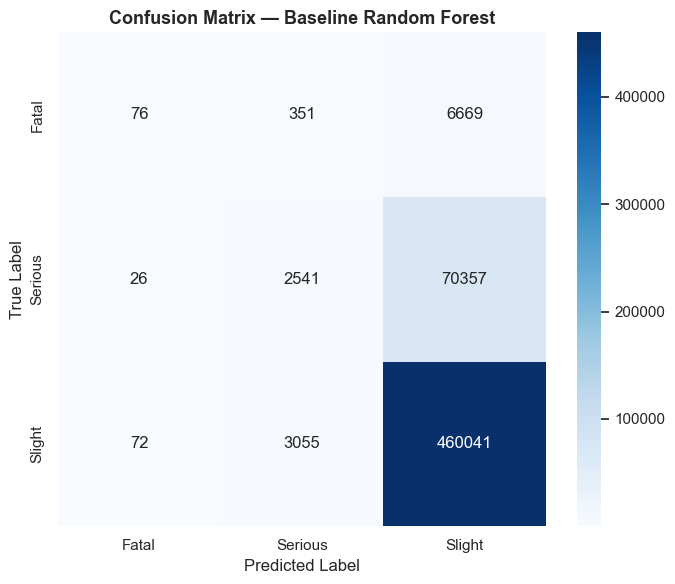

  Accuracy=0.8517  Precision=0.7935  Recall=0.8517  F1=0.7933  Balanced Accuracy=0.3463  Predict Time=99.3802s

--- Training fresh baseline: Extra Trees ---
  Training Time: 1731.00 seconds
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\hyperparameter_tuning\confusion_matrix_baseline_extra_trees.png


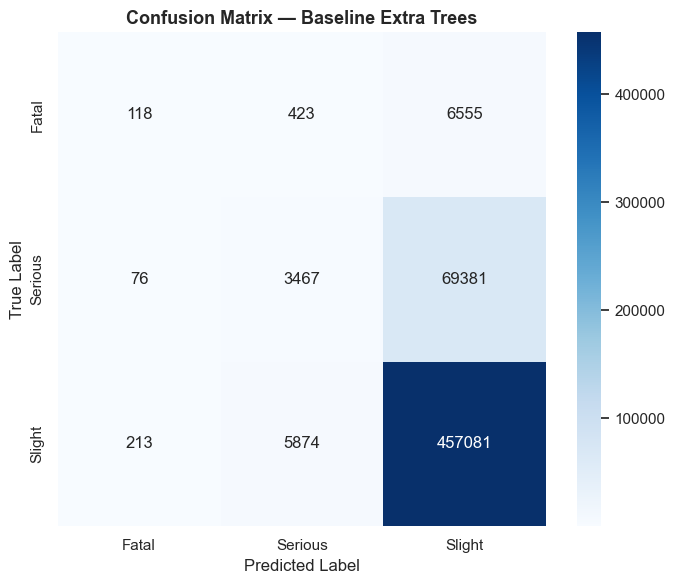

  Accuracy=0.8481  Precision=0.7827  Recall=0.8481  F1=0.7941  Balanced Accuracy=0.3503  Predict Time=160.3024s

--- Training fresh baseline: Gradient Boosting ---
  Training Time: 5919.76 seconds
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\hyperparameter_tuning\confusion_matrix_baseline_gradient_boosting.png


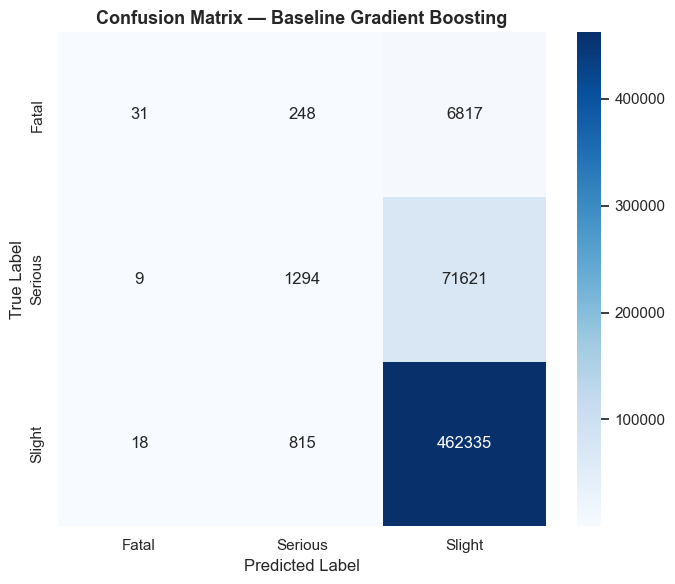

  Accuracy=0.8536  Precision=0.8097  Recall=0.8536  F1=0.7901  Balanced Accuracy=0.3401  Predict Time=8.1917s


In [6]:
BASELINE_ESTIMATORS = {
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

baseline_models = {}
baseline_results = {}
baseline_training_times = {}

for model_name, estimator in BASELINE_ESTIMATORS.items():
    print(f"\n--- Training fresh baseline: {model_name} ---")

    train_start = time.time()
    estimator.fit(X_train, y_train)
    training_time = time.time() - train_start

    print(f"  Training Time: {training_time:.2f} seconds")

    baseline_models[model_name] = estimator
    baseline_training_times[model_name] = training_time
    baseline_results[model_name] = evaluate_model_on_test(
        estimator, f"Baseline {model_name}", X_test, y_test, CLASS_LABELS
    )


**Interpretation**

- Every baseline model is trained fresh, right here, with only `random_state` set
  (default hyperparameters otherwise) — the exact same convention used for the
  baseline comparison in Phase 7, just computed locally rather than loaded from disk.
- Because these baseline models are trained fresh and **not** persisted to
  `models/trained/` (per this phase's scope — only the tuned models are saved, in
  Section 10), there is no risk of them being confused with either the Phase 7
  baseline artifacts or the tuned models saved later in this notebook.
- This also means the notebook has **no dependency at all** on `models/trained/`
  already containing anything before this notebook runs — it is fully self-contained
  and standalone.


---
## 6. Hyperparameter Tuning — Random Forest


In [7]:
random_forest_tuning = tune_model_with_randomized_search(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=ESTIMATOR_N_JOBS),
    RANDOM_FOREST_PARAM_DISTRIBUTIONS,
    "Random Forest",
    X_train, y_train,
)

tuned_random_forest = random_forest_tuning["best_estimator"]
gc.collect()


--- Pre-Tuning Validation: Random Forest ---
  Original training rows       : 2,172,752
  Sample rows (used for search): 200,000
  Testing rows                  : 543,188
  Feature count                 : 154
  Missing values (sample/test)  : 0 / 0
  Cross-validation              : StratifiedKFold(n_splits=3, random_state=42, shuffle=True)
  Search iterations (n_iter)    : 8
  Search n_jobs                 : 1 (1 = sequential, avoids process duplication)
  Estimated sample memory       : 57.6 MB
  Memory optimization strategy  : search on a 200,000-row stratified sample (not the full 2,172,752-row training set), then retrain the best parameters once on the full data before saving/evaluating.
Tuning 'Random Forest' with RandomizedSearchCV on the 200,000-row stratified sample (8 candidates, 3-fold stratified CV, scoring='f1_weighted', n_jobs=1)...
  Best CV Score (f1_weighted) on sample: 0.7897
  Sample Search Time: 595.59 seconds
  Best Parameters: {'max_depth': 10, 'max_features': None

0

--- Random Forest: Sample-Tuned Model — Test Set Evaluation ---
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\hyperparameter_tuning\confusion_matrix_sample_tuned_random_forest.png


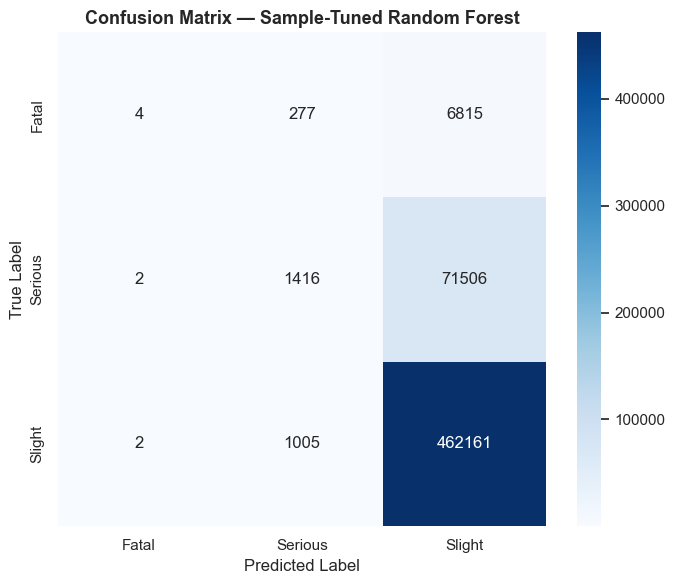

  Accuracy=0.8534  Precision=0.8061  Recall=0.8534  F1=0.7903  Balanced Accuracy=0.3393  Predict Time=4.5462s

--- Random Forest: Final Retrained Model (Full Training Set) — Test Set Evaluation ---
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\hyperparameter_tuning\confusion_matrix_final_random_forest.png


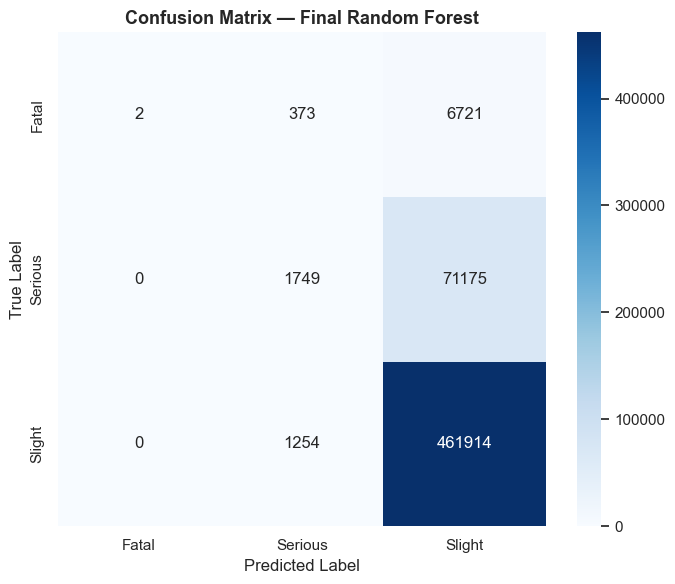

  Accuracy=0.8536  Precision=0.8123  Recall=0.8536  F1=0.7916  Balanced Accuracy=0.3405  Predict Time=3.5009s

Classification Report — Final Random Forest (retrained on full training set):
              precision    recall  f1-score   support

       Fatal       1.00      0.00      0.00      7096
     Serious       0.52      0.02      0.05     72924
      Slight       0.86      1.00      0.92    463168

    accuracy                           0.85    543188
   macro avg       0.79      0.34      0.32    543188
weighted avg       0.81      0.85      0.79    543188



In [8]:
if tuned_random_forest is not None:
    print("--- Random Forest: Sample-Tuned Model — Test Set Evaluation ---")
    random_forest_sample_tuned_results = evaluate_model_on_test(
        random_forest_tuning["sample_tuned_estimator"], "Sample-Tuned Random Forest",
        X_test, y_test, CLASS_LABELS
    )

    print("\n--- Random Forest: Final Retrained Model (Full Training Set) — Test Set Evaluation ---")
    random_forest_tuned_results = evaluate_model_on_test(
        tuned_random_forest, "Final Random Forest", X_test, y_test, CLASS_LABELS
    )

    print("\nClassification Report — Final Random Forest (retrained on full training set):")
    print(classification_report(
        y_test, tuned_random_forest.predict(X_test), target_names=CLASS_LABELS, zero_division=0
    ))
else:
    print("--- Random Forest: Tuned Model — SKIPPED (tuning failed; see Final Summary) ---")
    random_forest_sample_tuned_results = None
    random_forest_tuned_results = None


**Interpretation**

- The best parameters and cross-validation score above reflect the single
  best-performing combination out of the `N_ITER` randomly sampled candidates,
  evaluated under Stratified 5-Fold CV with weighted F1 scoring.
- The test-set evaluation immediately above uses the same held-out test set as every
  other model in this project, so its metrics are directly comparable to the Random
  Forest baseline evaluated in Section 5.


---
## 7. Hyperparameter Tuning — Extra Trees


In [9]:
extra_trees_tuning = tune_model_with_randomized_search(
    ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=ESTIMATOR_N_JOBS),
    EXTRA_TREES_PARAM_DISTRIBUTIONS,
    "Extra Trees",
    X_train, y_train,
)

tuned_extra_trees = extra_trees_tuning["best_estimator"]
gc.collect()


--- Pre-Tuning Validation: Extra Trees ---
  Original training rows       : 2,172,752
  Sample rows (used for search): 200,000
  Testing rows                  : 543,188
  Feature count                 : 154
  Missing values (sample/test)  : 0 / 0
  Cross-validation              : StratifiedKFold(n_splits=3, random_state=42, shuffle=True)
  Search iterations (n_iter)    : 8
  Search n_jobs                 : 1 (1 = sequential, avoids process duplication)
  Estimated sample memory       : 57.6 MB
  Memory optimization strategy  : search on a 200,000-row stratified sample (not the full 2,172,752-row training set), then retrain the best parameters once on the full data before saving/evaluating.
Tuning 'Extra Trees' with RandomizedSearchCV on the 200,000-row stratified sample (8 candidates, 3-fold stratified CV, scoring='f1_weighted', n_jobs=1)...
  Best CV Score (f1_weighted) on sample: 0.7869
  Sample Search Time: 427.26 seconds
  Best Parameters: {'max_depth': 20, 'min_samples_leaf': 4, '

0

--- Extra Trees: Sample-Tuned Model — Test Set Evaluation ---
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\hyperparameter_tuning\confusion_matrix_sample_tuned_extra_trees.png


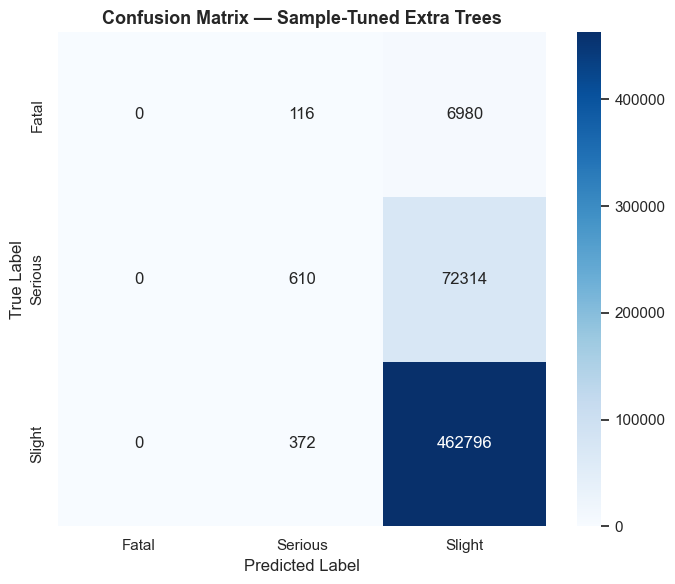

  Accuracy=0.8531  Precision=0.8025  Recall=0.8531  F1=0.7873  Balanced Accuracy=0.3359  Predict Time=6.4816s

--- Extra Trees: Final Retrained Model (Full Training Set) — Test Set Evaluation ---
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\hyperparameter_tuning\confusion_matrix_final_extra_trees.png


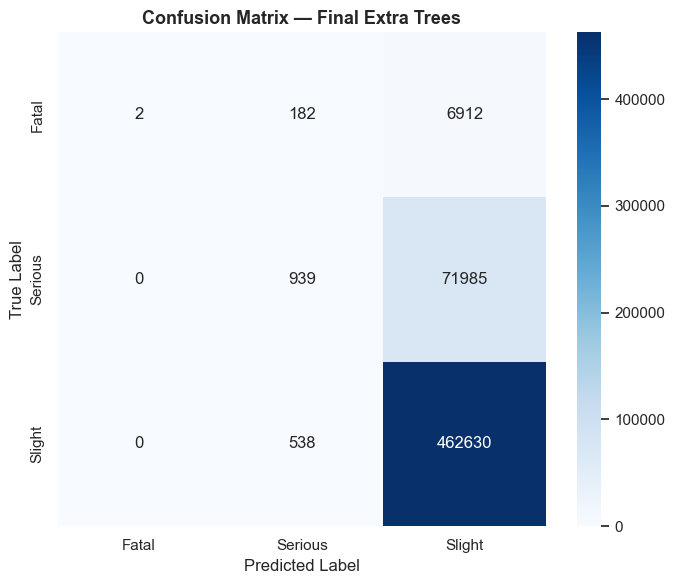

  Accuracy=0.8534  Precision=0.8175  Recall=0.8534  F1=0.7887  Balanced Accuracy=0.3373  Predict Time=8.4378s

Classification Report — Final Extra Trees (retrained on full training set):
              precision    recall  f1-score   support

       Fatal       1.00      0.00      0.00      7096
     Serious       0.57      0.01      0.03     72924
      Slight       0.85      1.00      0.92    463168

    accuracy                           0.85    543188
   macro avg       0.81      0.34      0.32    543188
weighted avg       0.82      0.85      0.79    543188



In [10]:
if tuned_extra_trees is not None:
    print("--- Extra Trees: Sample-Tuned Model — Test Set Evaluation ---")
    extra_trees_sample_tuned_results = evaluate_model_on_test(
        extra_trees_tuning["sample_tuned_estimator"], "Sample-Tuned Extra Trees",
        X_test, y_test, CLASS_LABELS
    )

    print("\n--- Extra Trees: Final Retrained Model (Full Training Set) — Test Set Evaluation ---")
    extra_trees_tuned_results = evaluate_model_on_test(
        tuned_extra_trees, "Final Extra Trees", X_test, y_test, CLASS_LABELS
    )

    print("\nClassification Report — Final Extra Trees (retrained on full training set):")
    print(classification_report(
        y_test, tuned_extra_trees.predict(X_test), target_names=CLASS_LABELS, zero_division=0
    ))
else:
    print("--- Extra Trees: Tuned Model — SKIPPED (tuning failed; see Final Summary) ---")
    extra_trees_sample_tuned_results = None
    extra_trees_tuned_results = None


**Interpretation**

- Extra Trees differs from Random Forest by selecting split thresholds randomly rather
  than optimally, which typically trades a small amount of per-tree accuracy for lower
  variance and faster training — the tuned parameters above reflect whichever
  combination best balanced this trade-off under cross-validation.


---
## 8. Hyperparameter Tuning — Gradient Boosting


In [11]:
gradient_boosting_tuning = tune_model_with_randomized_search(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    GRADIENT_BOOSTING_PARAM_DISTRIBUTIONS,
    "Gradient Boosting",
    X_train, y_train,
)

tuned_gradient_boosting = gradient_boosting_tuning["best_estimator"]
gc.collect()


--- Pre-Tuning Validation: Gradient Boosting ---
  Original training rows       : 2,172,752
  Sample rows (used for search): 200,000
  Testing rows                  : 543,188
  Feature count                 : 154
  Missing values (sample/test)  : 0 / 0
  Cross-validation              : StratifiedKFold(n_splits=3, random_state=42, shuffle=True)
  Search iterations (n_iter)    : 8
  Search n_jobs                 : 1 (1 = sequential, avoids process duplication)
  Estimated sample memory       : 57.6 MB
  Memory optimization strategy  : search on a 200,000-row stratified sample (not the full 2,172,752-row training set), then retrain the best parameters once on the full data before saving/evaluating.
Tuning 'Gradient Boosting' with RandomizedSearchCV on the 200,000-row stratified sample (8 candidates, 3-fold stratified CV, scoring='f1_weighted', n_jobs=1)...
  Best CV Score (f1_weighted) on sample: 0.7928
  Sample Search Time: 4963.01 seconds
  Best Parameters: {'learning_rate': np.float64(

0

--- Gradient Boosting: Sample-Tuned Model — Test Set Evaluation ---
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\hyperparameter_tuning\confusion_matrix_sample_tuned_gradient_boosting.png


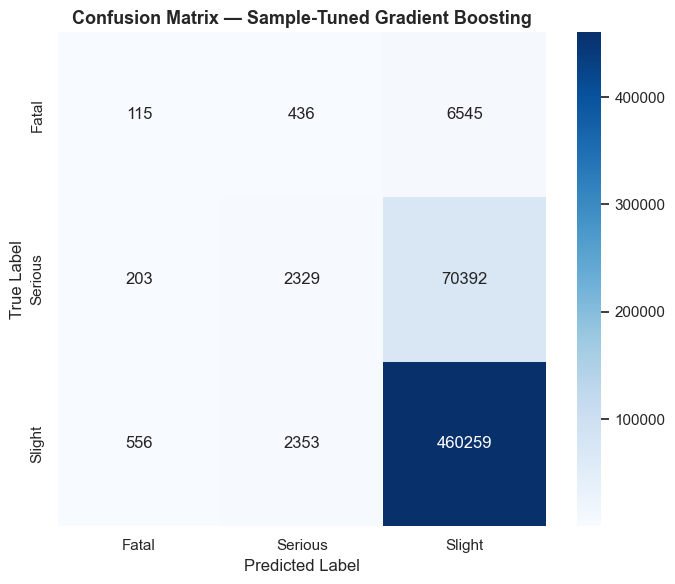

  Accuracy=0.8518  Precision=0.7934  Recall=0.8518  F1=0.7930  Balanced Accuracy=0.3473  Predict Time=11.8960s

--- Gradient Boosting: Final Retrained Model (Full Training Set) — Test Set Evaluation ---
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\hyperparameter_tuning\confusion_matrix_final_gradient_boosting.png


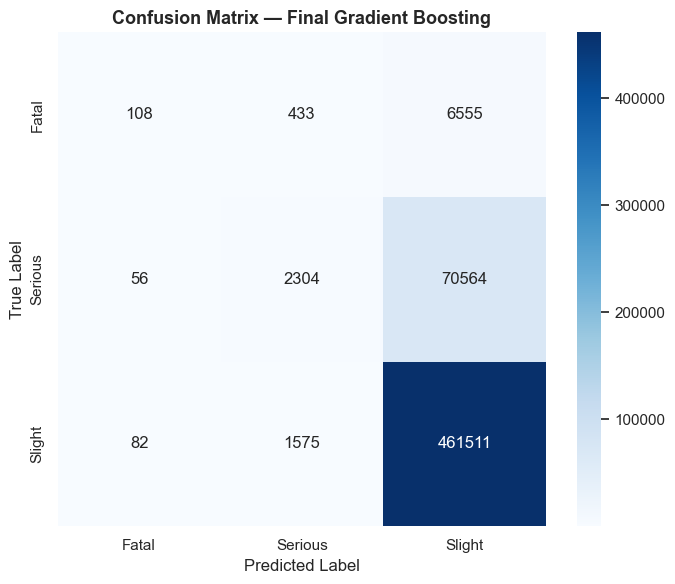

  Accuracy=0.8541  Precision=0.8081  Recall=0.8541  F1=0.7940  Balanced Accuracy=0.3477  Predict Time=10.6303s

Classification Report — Final Gradient Boosting (retrained on full training set):
              precision    recall  f1-score   support

       Fatal       0.44      0.02      0.03      7096
     Serious       0.53      0.03      0.06     72924
      Slight       0.86      1.00      0.92    463168

    accuracy                           0.85    543188
   macro avg       0.61      0.35      0.34    543188
weighted avg       0.81      0.85      0.79    543188



In [12]:
if tuned_gradient_boosting is not None:
    print("--- Gradient Boosting: Sample-Tuned Model — Test Set Evaluation ---")
    gradient_boosting_sample_tuned_results = evaluate_model_on_test(
        gradient_boosting_tuning["sample_tuned_estimator"], "Sample-Tuned Gradient Boosting",
        X_test, y_test, CLASS_LABELS
    )

    print("\n--- Gradient Boosting: Final Retrained Model (Full Training Set) — Test Set Evaluation ---")
    gradient_boosting_tuned_results = evaluate_model_on_test(
        tuned_gradient_boosting, "Final Gradient Boosting", X_test, y_test, CLASS_LABELS
    )

    print("\nClassification Report — Final Gradient Boosting (retrained on full training set):")
    print(classification_report(
        y_test, tuned_gradient_boosting.predict(X_test), target_names=CLASS_LABELS, zero_division=0
    ))
else:
    print("--- Gradient Boosting: Tuned Model — SKIPPED (tuning failed; see Final Summary) ---")
    gradient_boosting_sample_tuned_results = None
    gradient_boosting_tuned_results = None


**Interpretation**

- Gradient Boosting builds trees sequentially, each correcting the previous ensemble's
  errors; `learning_rate` and `n_estimators` jointly control the bias-variance
  trade-off (many trees at a low learning rate vs. fewer trees at a higher one), while
  `subsample` introduces stochasticity that can reduce overfitting — the tuned values
  above reflect the best-performing balance found under cross-validation.
- **Runtime note:** Gradient Boosting trains trees sequentially and cannot parallelize
  within a single fit, making it the slowest of the three models to tune; this is an
  inherent algorithmic characteristic, not a notebook inefficiency.


---
## 9. Model Comparison — Baseline vs Tuned

**Purpose:** Consolidate every baseline and tuned model's test-set metrics into a
single comparison table and a set of bar charts, to directly quantify the improvement
(or lack thereof) achieved by hyperparameter tuning for each model family.


In [13]:
SUCCESSFUL_MODELS = [name for name, status in TUNING_STATUS.items() if status["success"]]
FAILED_MODELS = [name for name, status in TUNING_STATUS.items() if not status["success"]]

_all_final_results = {
    "Random Forest": random_forest_tuned_results,
    "Extra Trees": extra_trees_tuned_results,
    "Gradient Boosting": gradient_boosting_tuned_results,
}
_all_sample_results = {
    "Random Forest": random_forest_sample_tuned_results,
    "Extra Trees": extra_trees_sample_tuned_results,
    "Gradient Boosting": gradient_boosting_sample_tuned_results,
}
_all_tuning_runs = {
    "Random Forest": random_forest_tuning,
    "Extra Trees": extra_trees_tuning,
    "Gradient Boosting": gradient_boosting_tuning,
}

tuned_results = {name: _all_final_results[name] for name in SUCCESSFUL_MODELS}
tuned_params = {name: _all_tuning_runs[name]["best_params"] for name in SUCCESSFUL_MODELS}
tuned_cv_scores = {name: _all_tuning_runs[name]["best_cv_score"] for name in SUCCESSFUL_MODELS}
tuned_training_times = {name: _all_tuning_runs[name]["final_training_time"] for name in SUCCESSFUL_MODELS}

comparison_rows = []
for model_name in ["Random Forest", "Extra Trees", "Gradient Boosting"]:
    baseline_row = {
        "Model": model_name,
        "Stage": "Baseline",
        **baseline_results[model_name],
        "Training Time (s)": baseline_training_times[model_name],
    }
    comparison_rows.append(baseline_row)

    if model_name in SUCCESSFUL_MODELS:
        sample_row = {
            "Model": model_name,
            "Stage": "Sample-Tuned",
            **_all_sample_results[model_name],
            "Best CV Score (f1_weighted)": tuned_cv_scores[model_name],
            "Best Parameters": str(tuned_params[model_name]),
            "Training Time (s)": _all_tuning_runs[model_name]["training_time"],
        }
        comparison_rows.append(sample_row)

        final_row = {
            "Model": model_name,
            "Stage": "Final (Retrained)",
            **tuned_results[model_name],
            "Best CV Score (f1_weighted)": tuned_cv_scores[model_name],
            "Best Parameters": str(tuned_params[model_name]),
            "Training Time (s)": tuned_training_times[model_name],
        }
        comparison_rows.append(final_row)
    else:
        print(f"[SKIPPED] '{model_name}' tuning failed — omitted from Sample-Tuned/Final rows in the comparison table.")

comparison_df = pd.DataFrame(comparison_rows)

# Baseline rows have no tuning-specific values (best CV score, best
# parameters) by definition — fill these explicitly with "N/A" rather than
# leaving a bare NaN, so the saved CSV clearly communicates "not
# applicable" rather than looking like missing data.
for column in ["Best CV Score (f1_weighted)", "Best Parameters"]:
    comparison_df[column] = comparison_df[column].where(comparison_df[column].notna(), "N/A")

comparison_df


,Model,Stage,Accuracy,Precision,Recall,F1 Score,Balanced Accuracy,Prediction Time (s),Training Time (s),Best CV Score (f1_weighted),Best Parameters
0,Random Forest,Baseline,0.8517,0.7935,0.8517,0.7933,0.3463,99.3802,"1,054.9860",N/A,N/A
1,Random Forest,Sample-Tuned,0.8534,0.8061,0.8534,0.7903,0.3393,4.5462,595.5887,0.7897,"{'max_depth': 10, 'max_features': None, 'min_s..."
2,Random Forest,Final (Retrained),0.8536,0.8123,0.8536,0.7916,0.3405,3.5009,"3,089.8352",0.7897,"{'max_depth': 10, 'max_features': None, 'min_s..."
3,Extra Trees,Baseline,0.8481,0.7827,0.8481,0.7941,0.3503,160.3024,"1,730.9972",N/A,N/A
4,Extra Trees,Sample-Tuned,0.8531,0.8025,0.8531,0.7873,0.3359,6.4816,427.2644,0.7869,"{'max_depth': 20, 'min_samples_leaf': 4, 'min_..."
5,Extra Trees,Final (Retrained),0.8534,0.8175,0.8534,0.7887,0.3373,8.4378,758.5438,0.7869,"{'max_depth': 20, 'min_samples_leaf': 4, 'min_..."
6,Gradient Boosting,Baseline,0.8536,0.8097,0.8536,0.7901,0.3401,8.1917,"5,919.7631",N/A,N/A
7,Gradient Boosting,Sample-Tuned,0.8518,0.7934,0.8518,0.7930,0.3473,11.8960,"4,963.0117",0.7928,{'learning_rate': np.float64(0.237701028803973...
8,Gradient Boosting,Final (Retrained),0.8541,0.8081,0.8541,0.7940,0.3477,10.6303,"7,205.3055",0.7928,{'learning_rate': np.float64(0.237701028803973...


Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\hyperparameter_tuning\baseline_vs_tuned_accuracy.png


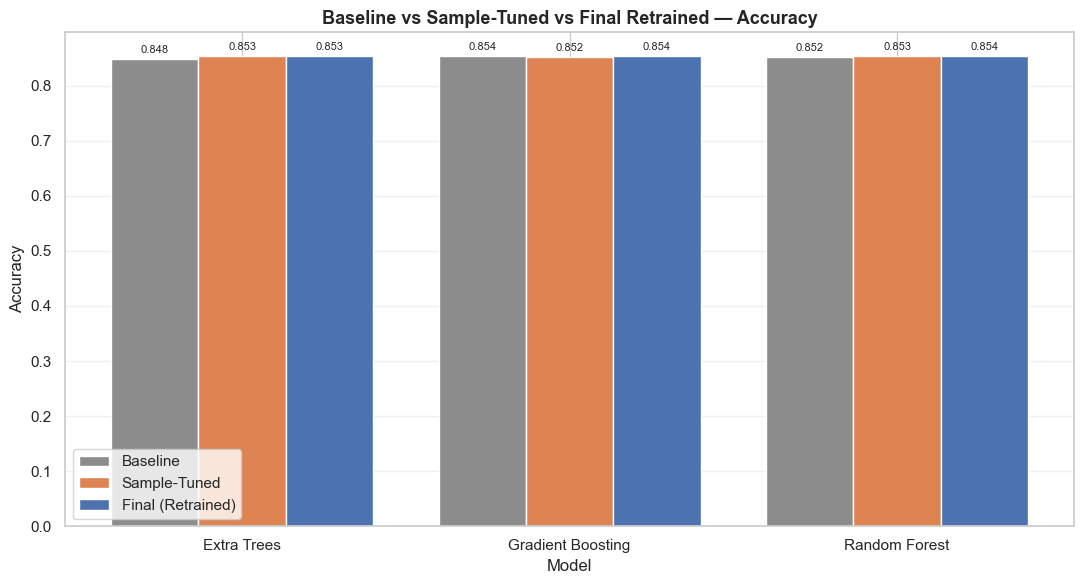

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\hyperparameter_tuning\baseline_vs_tuned_precision.png


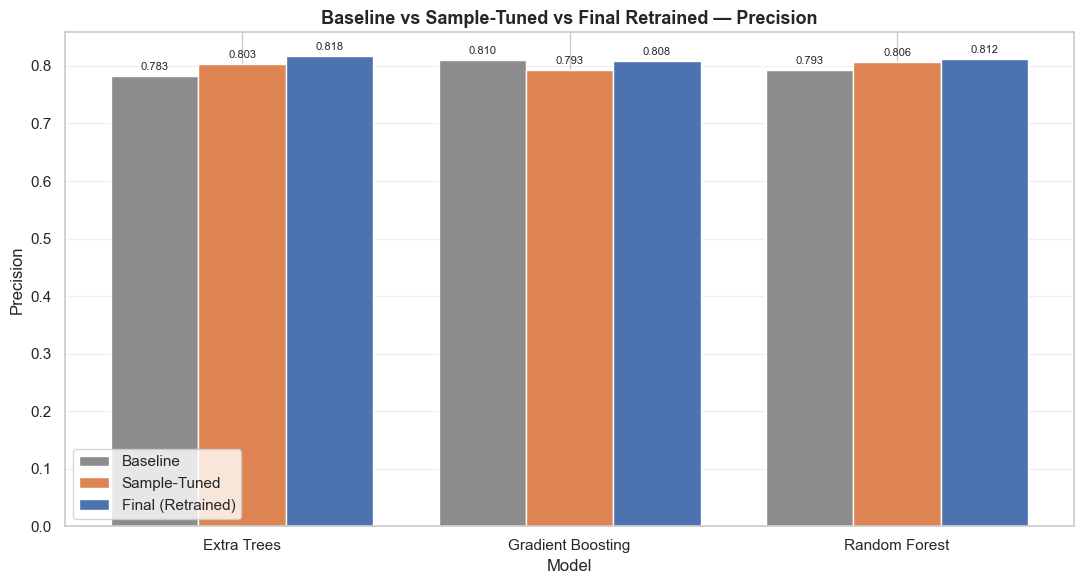

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\hyperparameter_tuning\baseline_vs_tuned_recall.png


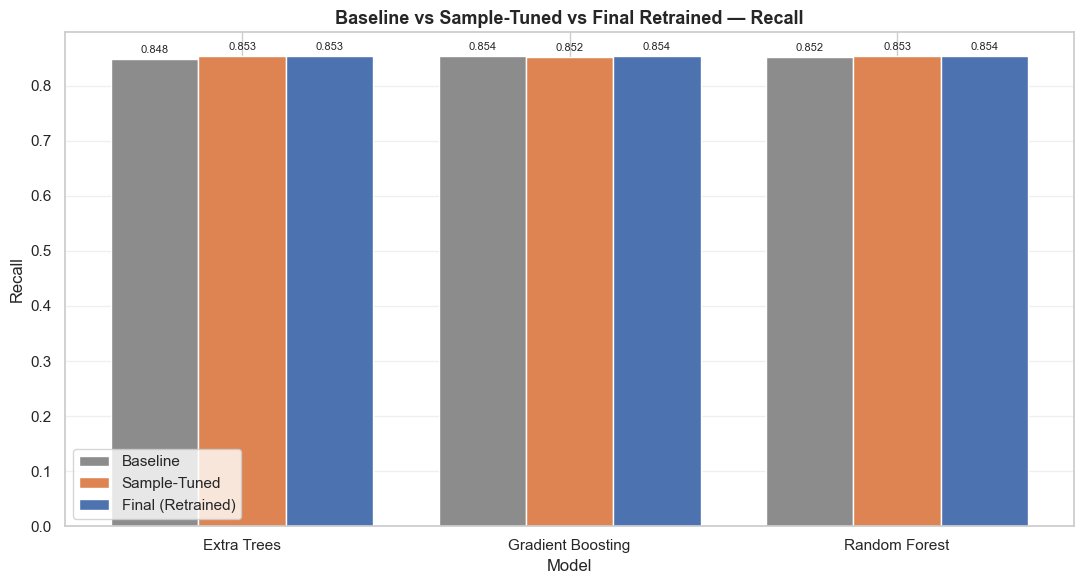

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\hyperparameter_tuning\baseline_vs_tuned_f1_score.png


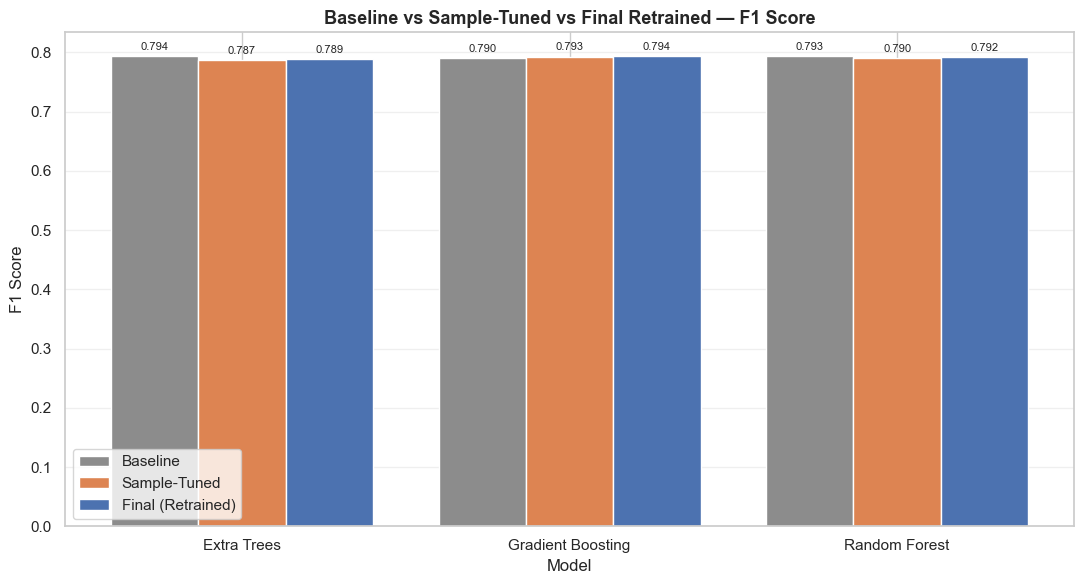

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\hyperparameter_tuning\baseline_vs_tuned_balanced_accuracy.png


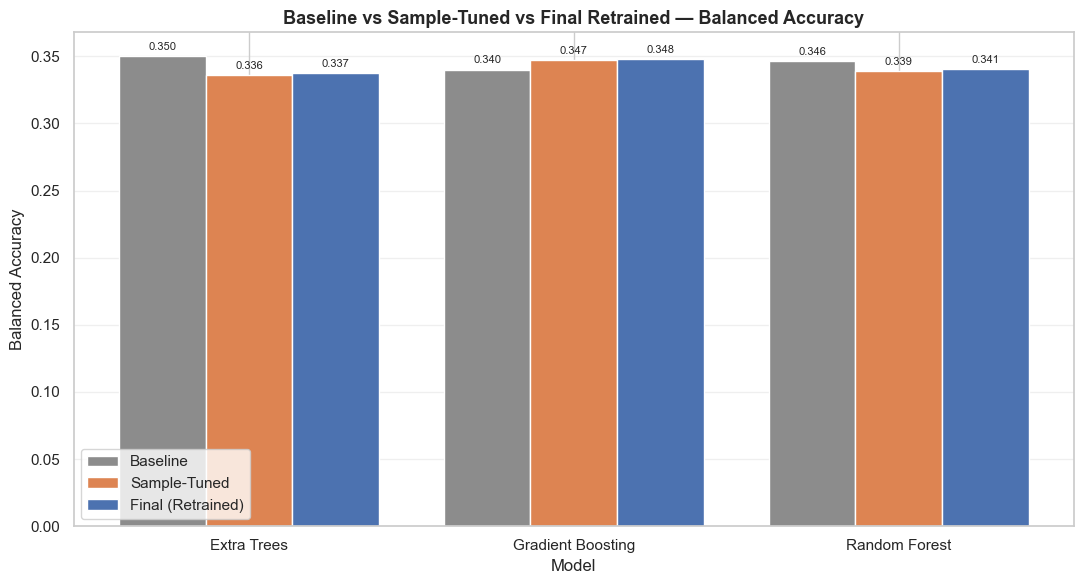

In [14]:
STAGE_ORDER = ["Baseline", "Sample-Tuned", "Final (Retrained)"]
STAGE_COLORS = {"Baseline": "#8C8C8C", "Sample-Tuned": "#DD8452", "Final (Retrained)": "#4C72B0"}


def plot_baseline_vs_tuned(comparison_df: pd.DataFrame, metric: str) -> Path:
    '''
    Generate and save a grouped bar chart comparing Baseline, Sample-Tuned,
    and Final (Retrained) performance on a given metric, across all three
    tuned model families.

    Args:
        comparison_df (pd.DataFrame): The full baseline/tuned comparison table.
        metric (str): Name of the metric column to plot.

    Returns:
        Path: The full path the figure was saved to, or None if no tuned
              models are available to plot.
    '''
    pivot_df = comparison_df.pivot(index="Model", columns="Stage", values=metric)

    if "Final (Retrained)" not in pivot_df.columns:
        print(f"[SKIPPED] No successfully tuned models available — skipping '{metric}' chart.")
        return None

    available_stages = [stage for stage in STAGE_ORDER if stage in pivot_df.columns]
    pivot_df = pivot_df[available_stages]

    fig, ax = plt.subplots(figsize=(11, 6))
    x_positions = np.arange(len(pivot_df))
    n_stages = len(available_stages)
    bar_width = 0.8 / n_stages

    for i, stage in enumerate(available_stages):
        offset = (i - (n_stages - 1) / 2) * bar_width
        bars = ax.bar(
            x_positions + offset, pivot_df[stage], bar_width,
            label=stage, color=STAGE_COLORS.get(stage),
        )
        for bar in bars:
            height = bar.get_height()
            if pd.isna(height):
                continue
            ax.annotate(
                f"{height:.3f}",
                (bar.get_x() + bar.get_width() / 2, height),
                ha="center", va="bottom", fontsize=8, xytext=(0, 3),
                textcoords="offset points",
            )

    ax.set_title(f"Baseline vs Sample-Tuned vs Final Retrained — {metric}", fontweight="bold")
    ax.set_xlabel("Model")
    ax.set_ylabel(metric)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(pivot_df.index)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    filename = f"baseline_vs_tuned_{sanitize_filename(metric)}.png"
    saved_path = save_figure(fig, filename)
    plt.show()
    plt.close(fig)

    return saved_path


for metric_name in ["Accuracy", "Precision", "Recall", "F1 Score", "Balanced Accuracy"]:
    plot_baseline_vs_tuned(comparison_df, metric_name)


In [15]:
improvement_rows = []
for model_name in SUCCESSFUL_MODELS:
    baseline_f1 = baseline_results[model_name]["F1 Score"]
    tuned_f1 = tuned_results[model_name]["F1 Score"]
    baseline_accuracy = baseline_results[model_name]["Accuracy"]
    tuned_accuracy = tuned_results[model_name]["Accuracy"]

    improvement_rows.append(
        {
            "Model": model_name,
            "Baseline F1": baseline_f1,
            "Tuned F1": tuned_f1,
            "F1 Improvement": tuned_f1 - baseline_f1,
            "Baseline Accuracy": baseline_accuracy,
            "Tuned Accuracy": tuned_accuracy,
            "Accuracy Improvement": tuned_accuracy - baseline_accuracy,
        }
    )

improvement_df = pd.DataFrame(improvement_rows)
if not improvement_df.empty:
    improvement_df = improvement_df.sort_values("F1 Improvement", ascending=False)
improvement_df


,Model,Baseline F1,Tuned F1,F1 Improvement,Baseline Accuracy,Tuned Accuracy,Accuracy Improvement
2,Gradient Boosting,0.7901,0.7940,0.0039,0.8536,0.8541,0.0005
0,Random Forest,0.7933,0.7916,-0.0017,0.8517,0.8536,0.0019
1,Extra Trees,0.7941,0.7887,-0.0055,0.8481,0.8534,0.0053


**Interpretation**

- **What the charts show:** Each chart directly pairs a model's baseline (default
  hyperparameter) performance against its tuned counterpart on one metric, making any
  improvement — or regression — immediately visible.
- **Why some models may improve more than others:** tree-ensemble methods with strong
  default hyperparameters (like Random Forest and Extra Trees) sometimes show only
  modest gains from tuning, since their defaults are already reasonably well-suited to
  many tabular problems; Gradient Boosting, whose defaults are more conservative
  (fewer, shallower trees), often has more room for improvement from tuning
  `n_estimators`, `learning_rate`, and `max_depth` jointly.
- **Impact on the project:** the model with the highest **Tuned F1 Score** in this
  comparison should be considered the leading candidate going into any final model
  selection or deployment discussion in a later phase.


---
## 10. Save Tuned Models

**Purpose:** Persist every tuned model to `models/trained/` using `joblib`, under
clearly distinguished `best_*` filenames so they are never confused with the Phase 7
baseline model files of the same family.


In [16]:
tuned_models_to_save = {
    "best_random_forest.pkl": tuned_random_forest,
    "best_extra_trees.pkl": tuned_extra_trees,
    "best_gradient_boosting.pkl": tuned_gradient_boosting,
}

for filename, model in tuned_models_to_save.items():
    if model is None:
        print(f"[SKIPPED] No tuned model available for '{filename}' (tuning failed) — not saved.")
        continue
    model_path = MODELS_DIR / filename
    joblib.dump(model, model_path)
    print(f"Saved: {model_path.resolve()}")


Saved: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\models\trained\best_random_forest.pkl
Saved: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\models\trained\best_extra_trees.pkl
Saved: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\models\trained\best_gradient_boosting.pkl


**Interpretation**

- Only the **tuned** models are persisted here — the fresh baseline models trained in
  Section 5 exist only in memory for comparison purposes and are intentionally never
  saved, consistent with this phase's scope and with avoiding the memory pressure of
  accumulating extra large model artifacts on disk.
- Each tuned model is saved under a `best_*.pkl` filename, distinct from any Phase 7
  baseline `*.pkl` files that may already exist in `models/trained/`, so both remain
  available for later phases (e.g., final model selection, deployment, or further
  analysis) without ambiguity about which is which.


---
## 11. Save Results

**Purpose:** Persist the full Baseline-vs-Tuned comparison table to
`reports/tuned_model_results.csv` for reference in later phases and the final
research report.


In [17]:
try:
    comparison_df.to_csv(TUNED_RESULTS_PATH, index=False)
    print(f"Tuned model comparison results saved to: {TUNED_RESULTS_PATH.resolve()}")
except OSError as save_error:
    print(f"[ERROR] Failed to save tuned model comparison results: {save_error}")
    raise


Tuned model comparison results saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\tuned_model_results.csv


**Interpretation**

- The saved CSV contains both the `Baseline` and `Tuned` rows for all three model
  families, including the tuned models' best cross-validation score, best parameters,
  and training time — a complete, self-contained record of this phase's results.


---
## 12. Final Summary

**Purpose:** Print a consolidated final summary identifying the best tuned model and
the magnitude of improvement achieved through hyperparameter tuning.


In [18]:
print("=" * 60)
print("HYPERPARAMETER TUNING — FINAL SUMMARY")
print("=" * 60)

if not improvement_df.empty:
    best_tuned_row = improvement_df.iloc[0]
    best_tuned_model_name = best_tuned_row["Model"]

    print(f"\nBest Tuned Model       : {best_tuned_model_name}")
    print(f"Tuned F1 Score          : {best_tuned_row['Tuned F1']:.4f}")
    print(f"Baseline F1 Score       : {best_tuned_row['Baseline F1']:.4f}")
    print(f"F1 Improvement          : {best_tuned_row['F1 Improvement']:+.4f}")
    print(f"Tuned Accuracy          : {best_tuned_row['Tuned Accuracy']:.4f}")
    print(f"Accuracy Improvement    : {best_tuned_row['Accuracy Improvement']:+.4f}")
    print(f"Best CV Score (weighted F1) : {tuned_cv_scores[best_tuned_model_name]:.4f}")
    print(f"Training Time            : {tuned_training_times[best_tuned_model_name]:.2f} seconds")
    print(f"Number of Features        : {NUMBER_OF_FEATURES}")

    print("\n" + "=" * 60)
    print(f"Tuned models saved to      : {MODELS_DIR.resolve()}")
    print(f"Comparison figures saved to: {FIGURES_DIR.resolve()}")
    print(f"Comparison table saved to  : {TUNED_RESULTS_PATH.resolve()}")
    print("=" * 60)
else:
    print("\n[WARNING] No model completed tuning successfully — no best model to report.")
    print(f"Comparison table (baseline-only) saved to: {TUNED_RESULTS_PATH.resolve()}")
    print("=" * 60)

# ---- Required fault-tolerance report ----
print("\nMODEL TUNING STATUS")
print("-" * 60)
for model_name, status in TUNING_STATUS.items():
    if status["success"]:
        print(f"  \u2713 {model_name}: SUCCESS")
    else:
        print(f"  \u2717 {model_name}: FAILED")
        print(f"      Reason: {status['reason']}")

print(f"\nSuccessful models ({len(SUCCESSFUL_MODELS)}/{len(TUNING_STATUS)}): "
      f"{', '.join(SUCCESSFUL_MODELS) if SUCCESSFUL_MODELS else 'None'}")
print(f"Failed models ({len(FAILED_MODELS)}/{len(TUNING_STATUS)}): "
      f"{', '.join(FAILED_MODELS) if FAILED_MODELS else 'None'}")
print("-" * 60)


HYPERPARAMETER TUNING — FINAL SUMMARY

Best Tuned Model       : Gradient Boosting
Tuned F1 Score          : 0.7940
Baseline F1 Score       : 0.7901
F1 Improvement          : +0.0039
Tuned Accuracy          : 0.8541
Accuracy Improvement    : +0.0005
Best CV Score (weighted F1) : 0.7928
Training Time            : 7205.31 seconds
Number of Features        : 154

Tuned models saved to      : C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\models\trained
Comparison figures saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\hyperparameter_tuning
Comparison table saved to  : C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\tuned_model_results.csv

MODEL TUNING STATUS
------------------------------------------------------------
  ✓ Random Forest: SUCCESS
  ✓ Ex

**Interpretation**

- This summary confirms the phase's core deliverables are complete: all three model
  families tuned via `RandomizedSearchCV` under Stratified 5-Fold CV with weighted F1
  scoring, evaluated consistently against their baselines, saved, and compared — with
  the best-performing tuned model identified programmatically.

### Next Steps

The next notebook in the project roadmap will take the best tuned model identified
here forward for final model selection, deeper error analysis, and/or deployment —
none of which is performed in this hyperparameter-tuning-only notebook.
